In [11]:
import requests
import pandas as pd

In [12]:
def get_history(coin, days):

    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"

    params = {
        "vs_currency" : "jpy",
        "days": days
    }

    response = requests.get(url,params=params)

    data = response.json()

    df = pd.DataFrame(
        data["prices"],
        columns=["Timestamp", "Price"]
    )

    df["Date"] = pd.to_datetime(
        df["Timestamp"],
        unit="ms"
    )

    df["Coin"] = coin

    return df.drop(columns="Timestamp")

In [13]:
coins = [
    "bitcoin",
    "ethereum",
    "solana"
]

all_df = []

for coin in coins:

    df = get_history(coin, 365)

    all_df.append(df)

crypto_df = pd.concat(
    all_df,
    ignore_index=True
)


In [14]:
crypto_df

,Price,Date,Coin
0,1.677231e+07,2025-08-04 00:00:00,bitcoin
1,1.698070e+07,2025-08-05 00:00:00,bitcoin
2,1.679588e+07,2025-08-06 00:00:00,bitcoin
3,1.688483e+07,2025-08-07 00:00:00,bitcoin
4,1.734690e+07,2025-08-08 00:00:00,bitcoin
...,...,...,...
1090,1.202030e+04,2026-07-30 00:00:00,solana
1091,1.193748e+04,2026-07-31 00:00:00,solana
1092,1.147372e+04,2026-08-01 00:00:00,solana
1093,1.131875e+04,2026-08-02 00:00:00,solana


前処理

In [15]:
crypto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   1095 non-null   float64       
 1   Date    1095 non-null   datetime64[ns]
 2   Coin    1095 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.8+ KB


In [16]:
crypto_df.head()

,Price,Date,Coin
0,1.677231e+07,2025-08-04,bitcoin
1,1.698070e+07,2025-08-05,bitcoin
2,1.679588e+07,2025-08-06,bitcoin
3,1.688483e+07,2025-08-07,bitcoin
4,1.734690e+07,2025-08-08,bitcoin


In [17]:
crypto_df.describe()

,Price,Date
count,1.095000e+03,1095
mean,4.597879e+06,2026-02-02 00:03:41.680365312
min,9.968505e+03,2025-08-04 00:00:00
25%,2.515421e+04,2025-11-03 00:00:00
50%,3.802492e+05,2026-02-02 00:00:00
75%,1.073585e+07,2026-05-04 00:00:00
max,1.896351e+07,2026-08-03 22:28:40
std,6.366922e+06,NaN


In [18]:
crypto_df["Date"] = pd.to_datetime(crypto_df["Date"])
crypto_df["Year"] = crypto_df["Date"].dt.year
crypto_df["Month"] = crypto_df["Date"].dt.month
crypto_df["Weekday"] = crypto_df["Date"].dt.day_name()

crypto_df

,Price,Date,Coin,Year,Month,Weekday
0,1.677231e+07,2025-08-04 00:00:00,bitcoin,2025,8,Monday
1,1.698070e+07,2025-08-05 00:00:00,bitcoin,2025,8,Tuesday
2,1.679588e+07,2025-08-06 00:00:00,bitcoin,2025,8,Wednesday
3,1.688483e+07,2025-08-07 00:00:00,bitcoin,2025,8,Thursday
4,1.734690e+07,2025-08-08 00:00:00,bitcoin,2025,8,Friday
...,...,...,...,...,...,...
1090,1.202030e+04,2026-07-30 00:00:00,solana,2026,7,Thursday
1091,1.193748e+04,2026-07-31 00:00:00,solana,2026,7,Friday
1092,1.147372e+04,2026-08-01 00:00:00,solana,2026,8,Saturday
1093,1.131875e+04,2026-08-02 00:00:00,solana,2026,8,Sunday


土日と平日で違いはある？

In [19]:
crypto_df["DayType"] = crypto_df["Weekday"].apply(
    lambda x:"Weekend"
    if x in ["Saturday","Sunday"]
    else "Weekday"
)
crypto_df

,Price,Date,Coin,Year,Month,Weekday,DayType
0,1.677231e+07,2025-08-04 00:00:00,bitcoin,2025,8,Monday,Weekday
1,1.698070e+07,2025-08-05 00:00:00,bitcoin,2025,8,Tuesday,Weekday
2,1.679588e+07,2025-08-06 00:00:00,bitcoin,2025,8,Wednesday,Weekday
3,1.688483e+07,2025-08-07 00:00:00,bitcoin,2025,8,Thursday,Weekday
4,1.734690e+07,2025-08-08 00:00:00,bitcoin,2025,8,Friday,Weekday
...,...,...,...,...,...,...,...
1090,1.202030e+04,2026-07-30 00:00:00,solana,2026,7,Thursday,Weekday
1091,1.193748e+04,2026-07-31 00:00:00,solana,2026,7,Friday,Weekday
1092,1.147372e+04,2026-08-01 00:00:00,solana,2026,8,Saturday,Weekend
1093,1.131875e+04,2026-08-02 00:00:00,solana,2026,8,Sunday,Weekend


In [20]:
result = (
    crypto_df.groupby("DayType")["Price"]
    .mean()
    .round(2)
)

print(result)

DayType
Weekday    4609988.09
Weekend    4567490.83
Name: Price, dtype: float64


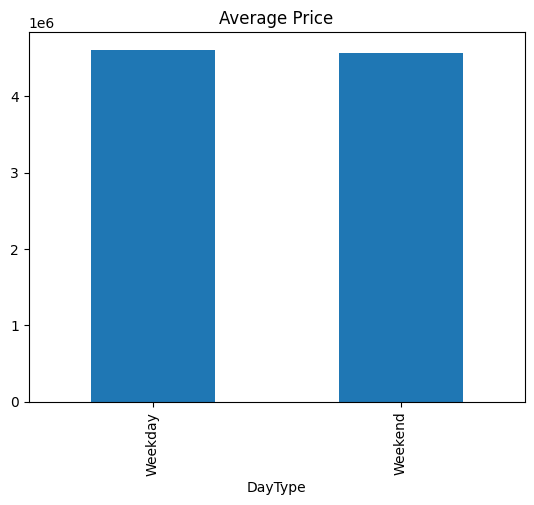

In [21]:
import matplotlib.pyplot as plt

result.plot(kind="bar")
plt.title("Average Price")

plt.show()

大きく下がった日の共通点

In [22]:
crypto_df["Return"] = crypto_df["Price"].pct_change() * 100

In [23]:
big_drop = (
    crypto_df.nsmallest(
        10,
        "Return"
    )
)

print(
    big_drop[
        [
            "Date",
            "Price",
            "Return"
        ]
    ]
)

          Date         Price     Return
365 2025-08-04  5.135549e+05 -94.865906
730 2025-08-04  2.376283e+04 -91.883715
551 2026-02-06  2.867031e+05 -14.692598
916 2026-02-06  1.232520e+04 -14.616535
798 2025-10-11  2.854450e+04 -14.555439
186 2026-02-06  9.868767e+06 -13.856195
433 2025-10-11  5.808419e+05 -12.058049
822 2025-11-04  2.546857e+04 -11.995828
671 2026-06-06  2.536762e+05 -10.546611
911 2026-02-01  1.636845e+04  -9.959873


月ごとの平均価格

In [24]:
monthly = (
    crypto_df.groupby(crypto_df["Date"].dt.month)["Price"]
    .mean()
    .round()
)

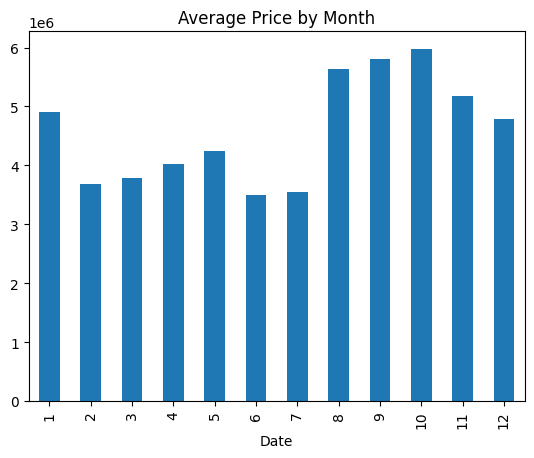

In [25]:
monthly.plot(
    kind="bar"
)

plt.title(
    "Average Price by Month"
)

plt.show()

どの年のボラティリティが大きい？

In [26]:
volatility = (
    crypto_df.groupby("Year")["Return"]
      .std()
      .round(2)
)

print(volatility)

Year
2025    7.09
2026    3.05
Name: Return, dtype: float64


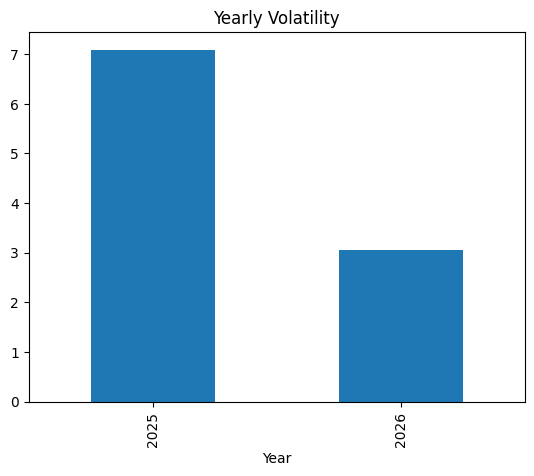

In [27]:
volatility.plot(
    kind="bar"
)

plt.title(
    "Yearly Volatility"
)

plt.show()

銘柄別ボラティリティ

In [28]:
volatility_coin = (
    crypto_df.groupby("Coin")["Return"]
      .std()
      .round(2)
)

print(volatility_coin)

Coin
bitcoin     2.28
ethereum    6.05
solana      6.05
Name: Return, dtype: float64


曜日ごとの平均リターン

In [29]:
big_drop_weekday = (
    big_drop.groupby("Weekday")["Return"]
      .mean()
      .round(2)
)

print(big_drop_weekday)

Weekday
Friday     -14.39
Monday     -93.37
Saturday   -12.39
Sunday      -9.96
Tuesday    -12.00
Name: Return, dtype: float64


30日移動平均線（MA30）

In [30]:
crypto_df["MA30"] = crypto_df["Price"].rolling(30).mean()


ValueError: x and y must have same first dimension, but have shapes (365,) and (1095,)

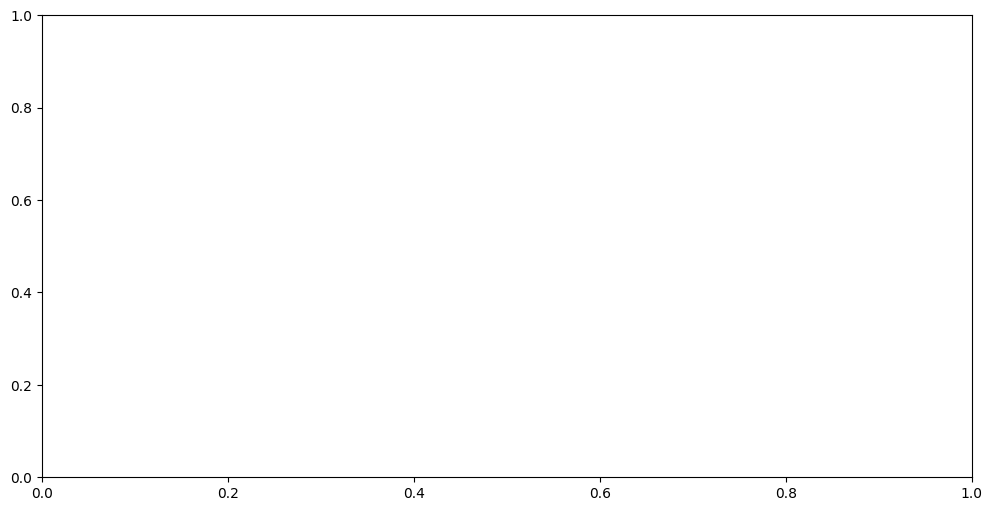

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, crypto_df["Price"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(df.index, crypto_df["MA30"], label="30-Day MA", color="blue", linewidth=1.5)

plt.title("30日移動平均線(MA30)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()